---
format:
  html:
    code-fold: false
execute:
  echo: true
---

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatthewAlexanderFisher/NCL-MAS3919/blob/main/content/practicals/assignment-setup.ipynb)

# Assignment Setup {.unnumbered}


Feature names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension



Task 1

1.1. Shape of X: (569, 30)
1.2. Shape of y: (569,)

2. Number of [0,1] {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}

3. Meaning of Malignant and Benign

4. Visualising the class distribution



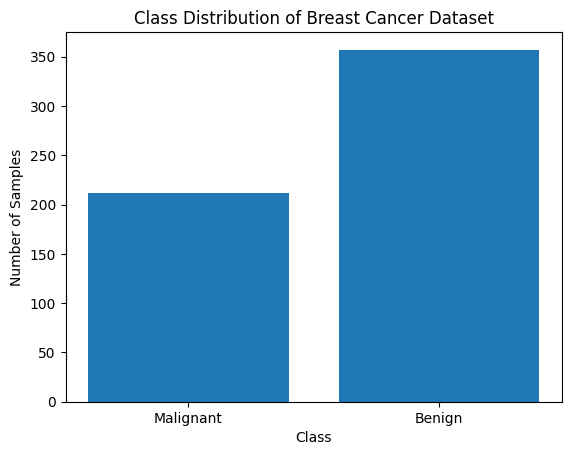

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

X = data.data
y = data.target

#TASK 1

#Understanding the data set (specifically the feature matrix X)
print("Feature names:")
for i in range(len(data.feature_names)):
    print(f"{i+1}. {data.feature_names[i]}")

print("")
print("")
print("")

print("\033[1mTask 1\033[0m") # Bold Task 1
print("")
#1.
print("\033[1m1.\033[0m1. Shape of X:",X.shape)
print("1.2. Shape of y:",y.shape)

print("")
#2.
unique, counts = np.unique(y, return_counts = True)
print("\033[1m2.\033[0m Number of [0,1]",dict(zip(unique, counts)))

#3
print("")
print("3. Meaning of Malignant and Benign")

#4
print("")
print("4. Visualising the class distribution")
print("")
plt.bar(unique, counts) # Corrected to visualize class distribution
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Breast Cancer Dataset")
plt.xticks(unique, ['Malignant', 'Benign']) # Assuming 0 is Malignant and 1 is Benign based on common interpretation
plt.show()







In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shapes after splitting:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes after splitting:
X_train shape: (455, 30)
y_train shape: (455,)
X_test shape: (114, 30)
y_test shape: (114,)


In [67]:
#Standardise the data

scaler = StandardScaler()
X_train_scaled = torch.from_numpy(scaler.fit_transform(X_train))
X_test_scaled = torch.from_numpy(scaler.transform(X_test))

print("Shapes after scaling:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("\nFirst 5 rows of X_train_scaled (example):")
print(X_train_scaled[:5])

type(X_train_scaled)

#Defining the model
class Net(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
    super().__init__()

    self.layer1 = nn.Linear(input_dim, hidden_dim)
    self.activation = nn.ReLU()
    self.layer2 = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h = self.layer1(x)
    h = self.activation(h)
    output = self.layer2(h)
    return output




Shapes after scaling:
X_train_scaled shape: torch.Size([455, 30])
X_test_scaled shape: torch.Size([114, 30])

First 5 rows of X_train_scaled (example):
tensor([[-1.0720e+00, -6.5842e-01, -1.0881e+00, -9.3927e-01, -1.3594e-01,
         -1.0087e+00, -9.6836e-01, -1.1020e+00,  2.8106e-01, -1.1323e-01,
         -7.0486e-01, -4.4094e-01, -7.4395e-01, -6.2980e-01,  7.4806e-04,
         -9.9157e-01, -6.9376e-01, -9.8328e-01, -5.9158e-01, -4.2897e-01,
         -1.0341e+00, -6.2350e-01, -1.0708e+00, -8.7653e-01, -1.6998e-01,
         -1.0388e+00, -1.0790e+00, -1.3505e+00, -3.5266e-01, -5.4138e-01],
        [ 1.7487e+00,  6.6502e-02,  1.7512e+00,  1.7456e+00,  1.2745e+00,
          8.4229e-01,  1.5199e+00,  1.9947e+00, -2.9305e-01, -3.2018e-01,
          1.2757e-01, -3.8138e-01,  9.4075e-02,  3.1752e-01,  6.3966e-01,
          8.7389e-02,  7.0845e-01,  1.1822e+00,  4.2621e-01,  7.4797e-02,
          1.2283e+00, -9.2833e-02,  1.1875e+00,  1.1044e+00,  1.5170e+00,
          2.4965e-01,  1.1786e+00

In [69]:
# Define the loss function and optimizer

# Instantiate the model
input_dim = X_train_scaled.shape[1]
hidden_dim = 64  # You can choose an appropriate hidden dimension
output_dim = 1   # Binary classification, so 1 output neuron (for BCEWithLogitsLoss)
model = Net(input_dim, hidden_dim, output_dim)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)